In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/home/mardhav-rayapati/Programming/Projects/Robot Sensor Analysis/data/session_1.csv")
total_rows = data["t_s"].count()
print(f"Total number of roes: {total_rows}") # Gives the total number of samples

In [ ]:
print(f"Total time: {max(data["t_s"])} seconds (~ {round(max(data["t_s"]) / 60, 2)} minutes)")

In [ ]:
dt = data["t_s"].diff().dropna()

mean_sampling_interval = np.mean(dt)
std_sampling_interval = np.std(dt)
max_deviation = np.max(np.abs(dt - 0.05))

mean_sampling_frequency = np.reciprocal(mean_sampling_interval)
std_sampling_frequency = np.std(np.reciprocal(dt))

print(f"Mean sampling interval: {mean_sampling_interval:.6f} s")
print(f"Standard deviation: {std_sampling_interval:.6f} s")
print(f"Maximum deviation: {max_deviation:.6f} s")
print(f"Mean sampling frequency: {mean_sampling_frequency:.6f} Hz")
print(f"Standard deviation of frequency: {std_sampling_frequency:.6f} Hz")

In [ ]:
distance_travelled_x = np.sum(np.abs(data["pos_x_mm"].diff()))
print(f"Distance travelled in x: {distance_travelled_x}")
distance_travelled_y = np.sum(np.abs(data["pos_y_mm"].diff()))
print(f"Distance travelled in y: {distance_travelled_y}")
total_distance = np.sqrt(np.square(distance_travelled_x) + np.square(distance_travelled_y))
print(f"Total distance: {total_distance}")

In [ ]:
plt.plot(data["pos_x_mm"], data["pos_y_mm"])
plt.title("Trajectory of robot")
plt.grid()
plt.axis("equal")
plt.xlabel("X position(mm)")
plt.ylabel("Y position(mm)")
plt.scatter(data["pos_x_mm"].iloc[0], data["pos_y_mm"].iloc[0], color = 'green', label = 'Start')
plt.scatter(data["pos_x_mm"].iloc[-1], data["pos_y_mm"].iloc[-1], color = 'red', label = 'End')
plt.legend()
plt.show()

In [ ]:
dx = data['pos_x_mm'].diff().dropna()
dy = data['pos_y_mm'].diff().dropna()
ds = np.sqrt(np.square(dx) + np.square(dy))
dt = data['t_s'].diff().dropna()

v = ds / dt

plt.plot(data['t_s'].iloc[1:], v)
plt.xlabel("Time (s)")
plt.ylabel("Speed (mm/s)")
plt.title("Robot Speed vs Time")
plt.grid()
plt.show()

In [ ]:
a = v.diff().dropna() / dt.iloc[1:]
plt.plot(data["t_s"].iloc[2:], a)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (mm/s^2)")
plt.title("Robot Acceleration vs Time")
plt.grid()
plt.show()

a.describe()

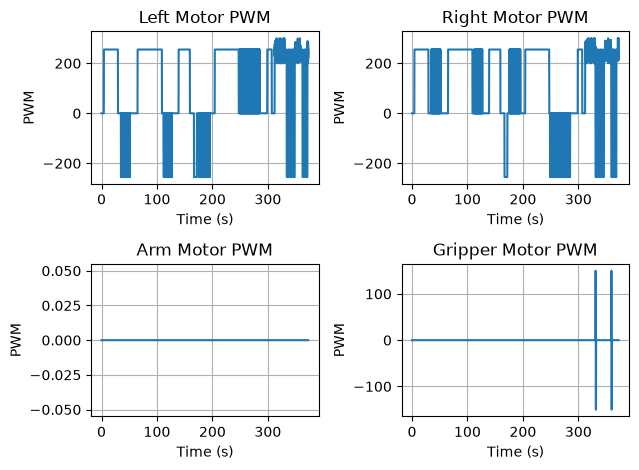

In [74]:
left_pwm = data['motor_left_pwm']
right_pwm = data['motor_right_pwm']
arm_pwm = data['motor_arm_pwm']
grip_pwm = data['motor_grip_pwm']

figure, axis = plt.subplots(2,2)

axis[0,0].plot(data["t_s"], left_pwm)
axis[0,1].plot(data["t_s"], right_pwm)
axis[1,0].plot(data["t_s"], arm_pwm)
axis[1,1].plot(data["t_s"], grip_pwm)

axis[0,0].set_title("Left Motor PWM")
axis[0,1].set_title("Right Motor PWM")
axis[1,0].set_title("Arm Motor PWM")
axis[1,1].set_title("Gripper Motor PWM")

for ax in axis.flat:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("PWM")
    ax.grid()

figure.tight_layout()

plt.show()